# Contextual bandits

## Introduction

Imagine you open a streaming platform for the first time. The platform has several channels, focused on various topics.

![A streaming platform showing five equally prominent channels: Technology, Sports, Cuisine, Car, and Art.](images/platform_catalog.svg)

The platform has to choose a channel to show you, but it knows nothing about your tastes.
It does not know what you watched, what you skipped, or what you liked. It needs to recommend something to you without any knowledge of your behavior towards the items of the platform.

![A new viewer with no watch history, facing five equally prominent channel choices.](images/contextual_choice.svg)

The solution to this issue is to use **contextual bandits**, a type of algorithm that balances exploration (trying new things) and exploitation (recommending what is known to be good) based on the context of the user.

![A simulated user provides context to a bandit, which recommends a channel, receives a rating, and updates its strategy.](images/bandit_feedback_loop.svg)

## Example scenario

Let's make it concrete with a small example.

Suppose the catalog contains only five streaming channels (five items): **Technology**, **Sports**, **Cuisine**, **Car**, and **Art**. Our goal is to build a recommendation system that provides the most relevant channel to each user, based on their context.

So we need a way to build this user context, and to simulate the users' behavior. To do this, I built a small simulator that mimics user interactions with this pretend platform. We treat it as a black box: our recommenders never look inside it, they only see the ratings it returns.

First, the simulator allows us to generate a user with some attributes:
- a country
- a time of day
- a device
- an age


In [1]:
from simulated_user import random_user

user = random_user()
print(user)

User(country=UK, time_of_day=evening, device_type=desktop, age=58)


In real life, a user would interact with the platform by watching, skipping, or liking content. Here, we mock this behavior with our simulator. The `rate_item` function returns a simulated rating, from 1 to 5, for a given user and item:


In [2]:
from simulated_user import User, Item, rate_item

item = Item.SPORTS
rating = rate_item(user, item)

print(f"Item: {item.value}")
print(f"Rating: {rating}/5")

Item: Sports
Rating: 3/5


This is one interaction: from a user and an item, we get a rating. But one interaction tells us almost nothing. In real life, we would use a history of interactions from many users.

So let's do just that! We ask a large number of users to rate each item, and build a historical dataset of user-item interactions.


In [3]:
import random

N = 1_000
items = tuple(Item)
historical_ratings = {}  # key: user, value: dict of item to list of ratings
for _ in range(N):
    user = random_user()
    for item in items:
        rating = rate_item(user, item)
        historical_ratings.setdefault(user, {}).setdefault(item, []).append(rating)


We now have a historical dataset of user-item interactions, and a simulator that can generate new ones.

One last thing: to compare recommenders fairly, we evaluate all of them on the same **fixed test set** of new users. A recommender picks one item for each test user, and we measure the average rating it gets.


In [4]:
test_users = [random_user() for _ in range(N)]

def evaluate(reco_for_user) -> float:
    ratings = [rate_item(user, reco_for_user(user)) for user in test_users]
    return sum(ratings) / len(ratings)


As a reference point, here is the score of a recommender that picks a channel at random. Any useful recommender should beat it:


In [5]:
def random_reco(user: User) -> Item:
    return random.choice(items)

print(f"Random: {evaluate(random_reco):.3f}")


Random: 3.273


## The global average: one answer for everyone

### a. Let's make a first guess

Let's start by assuming we know nothing about the new user. We do, however, have a history from other users. A reasonable first move is to recommend the channel (the item) with the highest average rating.

![Average rating of each channel; always recommend the best one.](images/global_average_baseline.svg)


### b. Let's build our first "recommender"

From the history of user-item interactions, we compute the average rating of each item:


In [6]:
avg_rating_by_item = {
    item: sum(sum(ratings[item]) for ratings in historical_ratings.values()) / N
    for item in items
}
best_item = max(avg_rating_by_item, key=avg_rating_by_item.get)

print({item.value: round(avg, 2) for item, avg in avg_rating_by_item.items()})
print(f"Best item: {best_item.value}")


{'Technology': 3.38, 'Sports': 3.4, 'Cuisine': 3.25, 'Car': 3.17, 'Art': 3.1}
Best item: Sports


Our "recommender" is now a simple function that ignores the user and always recommends this best item:


In [7]:
def global_reco(user: User) -> Item:
    return best_item


### c. How does this recommender perform?

Let's evaluate it on our test users:


In [8]:
print(f"Global average: {evaluate(global_reco):.3f}")


Global average: 3.424


It beats random, but it still ignores the person looking at the screen. Why not use the user's characteristics to provide a better recommendation?

## A group average: one answer for each country

### a. Let's use the information we already have

One item is the best when we mix everyone together. But perhaps it is not the best item in every country. We already know the user's country, so let's use it.

Instead of asking
> Which item is best for everybody?

We can ask a more targeted question:
> Which item is best for users from this country?


### b. Let's stop mixing everybody together

We stop putting every rating in the same pile. We make one pile per country, then compare the items inside the matching pile.

For a user from France, for example, the estimate for *Cuisine* uses ratings from French users only, not from the whole world. This is still an average, but it is now a **group average**.

![Each country's flag above its favorite channel.](images/country_item_cards.svg)


### c. Let's build it!

We reuse the same history, group it by country, and select each country's highest-rated item.


In [9]:
ratings_by_country = {}
for user, ratings_by_item in historical_ratings.items():
    country_ratings = ratings_by_country.setdefault(user.country, {})
    for item, ratings in ratings_by_item.items():
        country_ratings.setdefault(item, []).extend(ratings)

best_item_by_country = {
    country: max(ratings, key=lambda item: sum(ratings[item]) / len(ratings[item]))
    for country, ratings in ratings_by_country.items()
}
print({country.value: item.value for country, item in best_item_by_country.items()})

def country_reco(user: User) -> Item:
    return best_item_by_country[user.country]


{'DE': 'Sports', 'US': 'Technology', 'FR': 'Technology', 'UK': 'Cuisine', 'JP': 'Technology'}


### d. How does this recommender perform?

Let's evaluate it on the same test users:


In [10]:
print(f"Country average: {evaluate(country_reco):.3f}")


Country average: 3.647


Better than using no context at all! But can we do better?

## Tabular contextual bandit

### a. Let's build the context key

The country helped, so more context should help even more. Why not use the complete situation (the complete context) as the key? Instead of one pile per country, we build one pile for each unique combination of context features.

This is a **tabular contextual bandit**: the context is the user's characteristics, the action is the item we choose, and the reward is the rating the user gives to this item.

![A contextual bandit maps the user's context to a recommended item, then receives a reward.](images/context_action_reward.svg)

We store the rewards of each context/item pair in a table, so we can estimate which item is best for a new user in that context.


### b. What does the bandit table contain?

The table stores the average rating of each item for each combination of country, age, time of day, and device. A 20-year-old from France in the morning on mobile can then have a different favorite item from a 20-year-old from France in the evening on desktop.

![A tabular contextual bandit indexes five item estimates by country, age, time of day, and device; each row tracks the shown count and average rating.](images/tabular_bandit_table.svg)

Even our small simulator has (5 countries) × (3 times of day) × (2 devices) × (53 ages) = 1,590 possible contexts. With five items, that is almost 8,000 context/item estimates!

For every context/item pair, we keep two numbers: how many times the item was shown, and the average rating it received. Let's fill the table from the history:


In [11]:
bandit_table = {}  # key: (user, item), value: {"count", "average"}

def update_bandit(user: User, item: Item, rating: float) -> None:
    stats = bandit_table.setdefault((user, item), {"count": 0, "average": 0.0})
    stats["count"] += 1
    stats["average"] += (rating - stats["average"]) / stats["count"]

for user, ratings_by_item in historical_ratings.items():
    for item, ratings in ratings_by_item.items():
        for rating in ratings:
            update_bandit(user, item, rating)


### c. Let's recommend from the table

To recommend, we look up the user's context and pick the item with the highest average among the ones observed for this context. For a context the table has never seen, we have no evidence that one item beats another, so we pick at random.


In [12]:
def tabular_reco(user: User) -> Item:
    observed_items = [item for item in items if (user, item) in bandit_table]
    if not observed_items:
        return random.choice(items)
    return max(observed_items, key=lambda item: bandit_table[(user, item)]["average"])


### d. How does this recommender perform?


In [13]:
print(f"Tabular (offline): {evaluate(tabular_reco):.3f}")


Tabular (offline): 3.705


We improved our results again. But notice that every recommender so far is **offline**: it learns once from the history, then stays frozen. And the history is thin: 1,000 users spread over 1,590 contexts, so many entries rely on a single rating, and many contexts are missing entirely.

A bandit does not need to stay frozen. It can keep learning **online**: every time it recommends an item to a live user, the rating it gets back becomes a new row in the table.

## Online learning: the exploration-exploitation trade-off


Learning online raises a new question at each decision. **Exploitation** means choosing the item with the highest estimated rating: it uses what the bandit knows and usually gives a good immediate result. **Exploration** means trying another item, even if its estimate is lower or unknown: it may cost a lower rating now, but it produces information and can reveal a better item. A bandit that only exploits never corrects its early mistakes.

The **epsilon-greedy** rule makes this compromise explicit. With probability `epsilon`, it explores by choosing an item at random. Otherwise, it exploits. With `epsilon = 0.1`, it explores 10% of the time and exploits 90% of the time.

![A random draw splits epsilon-greedy decisions into exploration with probability epsilon and exploitation with probability one minus epsilon.](images/epsilon_greedy.svg)


In [14]:
epsilon = 0.1

def epsilon_greedy_reco(user: User) -> Item:
    if random.random() < epsilon:
        return random.choice(items)  # explore
    return tabular_reco(user)  # exploit


We do not start from scratch: the bandit continues from the table learned offline. It now serves 10,000 live users, and each rating goes back into the table immediately. The plot shows the running average rating of these live recommendations, exploration included.


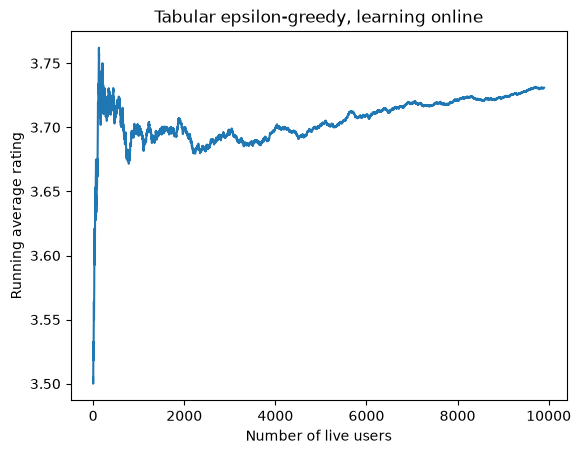

In [15]:
import matplotlib.pyplot as plt
import numpy as np

live_ratings = []
for _ in range(10_000):
    user = random_user()
    item = epsilon_greedy_reco(user)
    rating = rate_item(user, item)
    update_bandit(user, item, rating)  # learn online
    live_ratings.append(rating)

running_average = np.cumsum(live_ratings) / np.arange(1, len(live_ratings) + 1)
plt.plot(running_average[100:])  # skip the noisy start
plt.xlabel("Number of live users")
plt.ylabel("Running average rating")
plt.title("Tabular epsilon-greedy, learning online")
plt.show()


The running average includes the 10% of random explorations, so it is not directly comparable with the offline scores. To compare fairly, we evaluate the updated table on the same test users as before, without exploration:


In [16]:
print(f"Tabular (after online learning): {evaluate(tabular_reco):.3f}")


Tabular (after online learning): 3.827


The same table, fed with live ratings, now recommends better than it did offline. That is the power of online learning.

But the table has a structural limit. A real platform may know a user's language, location, subscription, recent history, device, and much more. One average per combination would need an enormous table, and far more ratings to fill each entry reliably. Worse, for a context it has never seen, the table knows nothing: it cannot **generalize**.


## Linear contextual bandit: learning from features

### a. What if the table is too big?

What if the system could learn that some contexts are related? A French user in the morning and a French user in the evening are not the same context, but they share the fact that they are French. A model can use these shared pieces of information when there is not enough data for each exact context.

Replacing the table with a model that predicts the reward of each item from features is the idea behind the **linear contextual bandit**.


### b. How can a model share information?

A linear model does not store one average per exact situation. It predicts the expected rating of each item from the user's features. Concretely, we build one linear model per item, and predict the rating of each item as:

$$
\widehat{r}(user, item) = \theta_{item}^{\mathsf{T}} x(user)
$$

where $x$ is the feature vector of the user, and $\theta_{item}$ the weights learned from past interactions.


### c. Let's build the model

For one item, suppose we observed users with features $x_1, \ldots, x_n$ and ratings $r_1, \ldots, r_n$. We want the weights whose predictions are closest to those ratings:

$$
\theta_{item} = \arg\min_{\theta} \sum_{j=1}^{n} \left(r_j - \theta^{\mathsf{T}} x_j\right)^2
$$

This least-squares problem has a closed-form solution, $A_{item}\,\theta_{item} = b_{item}$, with:

$$
A_{item} = \sum_{j} x_j x_j^{\mathsf{T}},
\qquad
b_{item} = \sum_{j} r_j x_j
$$

Both are sums, so learning online is easy: when a new rating $r$ arrives for features $x$, we add its contribution and solve again:

$$
A_{item} \leftarrow A_{item} + xx^{\mathsf{T}},
\qquad
b_{item} \leftarrow b_{item} + rx
$$

$A_{item}$ starts as the identity matrix, a small regularization that keeps the system solvable before any rating arrives. We keep the same epsilon-greedy rule to explore.


In [17]:
class LinearBandit:
    def __init__(self, n_features: int, epsilon: float = 0.1):
        self.epsilon = epsilon
        self.A = {item: np.eye(n_features) for item in items}
        self.b = {item: np.zeros(n_features) for item in items}
        self.theta = {item: np.zeros(n_features) for item in items}

    def best_item(self, x: np.ndarray) -> Item:
        return max(items, key=lambda item: self.theta[item] @ x)

    def choose(self, x: np.ndarray) -> Item:
        if random.random() < self.epsilon:
            return random.choice(items)  # explore
        return self.best_item(x)  # exploit

    def update(self, x: np.ndarray, item: Item, rating: float) -> None:
        self.A[item] += np.outer(x, x)
        self.b[item] += rating * x
        self.theta[item] = np.linalg.solve(self.A[item], self.b[item])


### d. Let's train and evaluate the model

The simulator's `user_to_features` turns a user into numbers: a constant, one-hot encodings of country, time of day and device, and a scaled age.

To see generalization at work, this bandit starts with **no history at all**. It learns only online, from 10,000 live users, as the tabular bandit did:


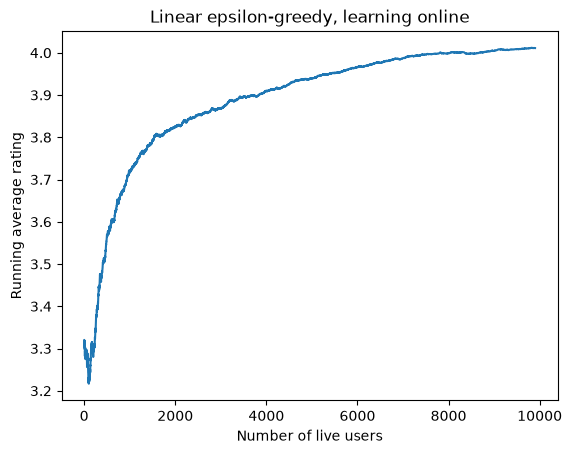

In [18]:
from simulated_user import user_to_features

bandit = LinearBandit(n_features=len(user_to_features(user)))
live_ratings = []
for _ in range(10_000):
    user = random_user()
    x = user_to_features(user)
    item = bandit.choose(x)
    rating = rate_item(user, item)
    bandit.update(x, item, rating)  # learn online
    live_ratings.append(rating)

running_average = np.cumsum(live_ratings) / np.arange(1, len(live_ratings) + 1)
plt.plot(running_average[100:])  # skip the noisy start
plt.xlabel("Number of live users")
plt.ylabel("Running average rating")
plt.title("Linear epsilon-greedy, learning online")
plt.show()


As before, we evaluate it on the test users without exploration, and ask it what to show a French user in the morning on mobile:


In [19]:
from simulated_user import Country, DeviceType, TimeOfDay

print(f"Linear: {evaluate(lambda user: bandit.best_item(user_to_features(user))):.3f}")

french_morning_user = User(Country.FR, TimeOfDay.MORNING, DeviceType.MOBILE, age=30)
print(f"French user, morning, mobile: {bandit.best_item(user_to_features(french_morning_user)).value}")


Linear: 4.228
French user, morning, mobile: Technology


Starting from nothing, the linear bandit beats the table. That is the main advantage of a model: we no longer keep a separate average for every possible situation. The user is described by features, and the model learns how each feature influences the rating of each channel. A French user in the morning and a French user in the evening are not complete strangers: they share the fact that they are French, so every rating teaches the model something about both.

Of course, this is not magic. Notice the recommendation for the French morning user: the model suggests Technology, the favorite of French users overall. It adds up the effect of "French" and the effect of "morning" separately, so it cannot learn that French users like Cuisine *specifically* in the morning. The features must be useful, and the relationship between features and rating must be reasonably linear.


## In summary

| Recommender | Learns | Average rating |
|---|---|---|
| Random | nothing | 3.27 |
| Global average | offline | 3.42 |
| Country average | offline | 3.65 |
| Tabular bandit | offline | 3.71 |
| Tabular bandit | offline, then online | 3.83 |
| Linear bandit | online only | 4.23 |

A contextual bandit learns as it goes: it uses the user's context to choose a channel, gets a rating back, and updates what it knows. It balances choosing what currently looks best with trying other channels. When exact contexts are sparse, a linear model shares what it learns across users with similar features.

That is one way to make recommendations. We can also use information about the items themselves, or learn from patterns in users' past choices. Let's look at those approaches next, starting with content-based and collaborative filtering.
